<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/009_900_LicencePlateGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-image pillow numpy matplotlib

Generated Plate: DL1CJI0001


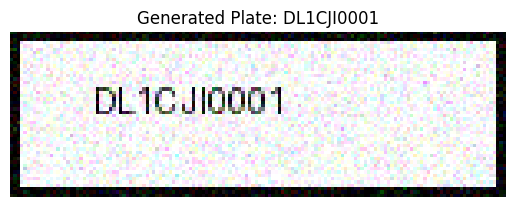

In [2]:
import numpy as np
import random
import string
from PIL import Image, ImageDraw, ImageFont
from skimage.util import random_noise
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

def generate_license_plate(text=None, size=(150, 50)):
    """Generates a synthetic license plate image."""
    if text is None:
        # Generate random 7-character plate
        text = ''.join(random.choices(string.ascii_uppercase + string.digits, k=7))

    # 1. Create base image (White background)
    img = Image.new('RGB', size, color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    # 2. Draw black border
    draw.rectangle([0, 0, size[0]-1, size[1]-1], outline="black", width=3)

    # 3. Add text (using a default font)
    # Note: For better results, load a font like 'Arial.ttf'
    font = ImageFont.load_default()

    # Rough centering
    text_width = 100
    text_height = 20
    position = ((size[0] - text_width) // 2, (size[1] - text_height) // 2)
    draw.text(position, text, fill="black", font=font)

    # Convert PIL image to numpy array for skimage
    plate_arr = np.array(img)

    # 4. Add Synthetic Noise using skimage
    # Add Gaussian noise
    noisy_plate = random_noise(plate_arr, mode='gaussian', var=0.01)

    # Convert back to uint8
    final_plate = (noisy_plate * 255).astype(np.uint8)

    return final_plate, text

# Generate and Display
plate_image, plate_text = generate_license_plate("DL1CJI0001")
print(f"Generated Plate: {plate_text}")

plt.imshow(plate_image)
plt.title(f"Generated Plate: {plate_text}")
plt.axis('off')
plt.show()